In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from dataset import load_imagenette, to_one_hot
from layers import Flatten, Dense
from model import Model
from functions import accuracy


Loading train images (10 classes)...
Loading val images...
X_train: (9469, 160, 160, 3), y_train: (9469,), y_train_oh: (9469, 10)
X_test:  (3925, 160, 160, 3), y_test:  (3925,), y_test_oh:  (3925, 10)


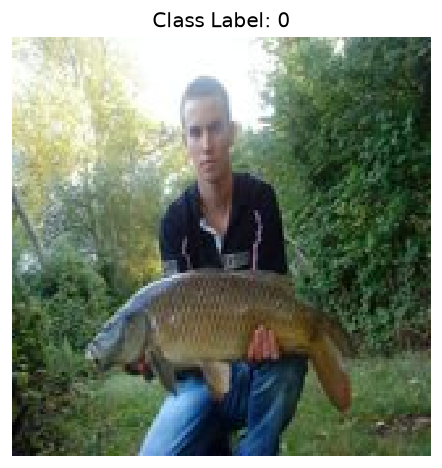

In [17]:
# Load dataset
X_train, y_train, X_test, y_test = load_imagenette(img_size=160)

y_train_oh = to_one_hot(y_train)
y_test_oh = to_one_hot(y_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, y_train_oh: {y_train_oh.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}, y_test_oh:  {y_test_oh.shape}")

# Display one sample
plt.figure(figsize=(4, 4), dpi=120)
plt.imshow(X_train[6], interpolation="nearest")
plt.title(f"Class Label: {y_train[0]}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
# Dataset selection for train / test
num_train = 3000
X_tr_sub = X_train[:num_train]
y_tr_sub = y_train[:num_train]
y_tr_oh_sub = y_train_oh[:num_train]

# Instantiate the model architecture.
flatten = Flatten()
dense1 = Dense(units=128, activation="relu")
dense2 = Dense(units=64, activation="relu")
dense3 = Dense(units=32, activation="relu")
dense4 = Dense(units=10, activation="softmax")

# combine all layers
model = Model(layers=[flatten, dense1, dense2, dense3, dense4])
model.compile(loss="categorical_crossentropy")

epochs = 15
batch_size = 64
lr = 0.05
history = {"loss": [], "accuracy": []}

print(f"Training FNN on {num_train} ImageNette samples...")

for epoch in range(1, epochs + 1):
    indices = np.random.permutation(num_train)
    X_shuffled = X_tr_sub[indices]
    y_oh_shuffled = y_tr_oh_sub[indices]

    epoch_loss = 0.0
    num_batches = int(np.ceil(num_train / batch_size))

    batch_iter = tqdm(range(num_batches), desc=f"Epoch {epoch:02d}/{epochs:02d}")
    for b in batch_iter:
        start = b * batch_size
        end = min(start + batch_size, num_train)

        X_batch = X_shuffled[start:end]
        y_oh_batch = y_oh_shuffled[start:end]

        # Forward Propagation
        y_pred, caches = model.forward(X_batch)
        loss = model.loss_fn(y_pred, y_oh_batch)
        epoch_loss += loss * (end - start)

        # Back propagation
        dA = model.loss_grad_fn(y_pred, y_oh_batch)
        model.backward(dA, caches, lr)

        batch_iter.set_postfix({"loss": f"{loss:.4f}"})

    avg_loss = epoch_loss / num_train

    # check accuracy of our model
    y_pred_full = model.predict(X_tr_sub)
    acc = accuracy(y_pred_full, y_tr_sub)

    history["loss"].append(avg_loss)
    history["accuracy"].append(acc)

    print(f"Epoch {epoch:02d} Summary - Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%\n")


Training FNN on 3000 ImageNette samples...


Epoch 01/15: 100%|██████████| 47/47 [00:16<00:00,  2.82it/s, loss=1.4561] 


Epoch 01 Summary - Loss: 3.3524 | Accuracy: 33.10%



Epoch 02/15: 100%|██████████| 47/47 [00:19<00:00,  2.36it/s, loss=1.2774]


Epoch 02 Summary - Loss: 1.3126 | Accuracy: 33.13%



...

Epoch 13 Summary - Loss: 0.9971 | Accuracy: 59.50%



Epoch 14/15: 100%|██████████| 47/47 [00:10<00:00,  4.59it/s, loss=1.0311]


Epoch 14 Summary - Loss: 0.9837 | Accuracy: 61.37%



Epoch 15/15: 100%|██████████| 47/47 [00:16<00:00,  2.77it/s, loss=0.9700]


Epoch 15 Summary - Loss: 0.9715 | Accuracy: 61.37%



In [ ]:
# Evaluate model performance using test set
y_test_pred = model.predict(X_test[:1200])
test_acc = accuracy(y_test_pred, y_test[:1200])
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 88.50%


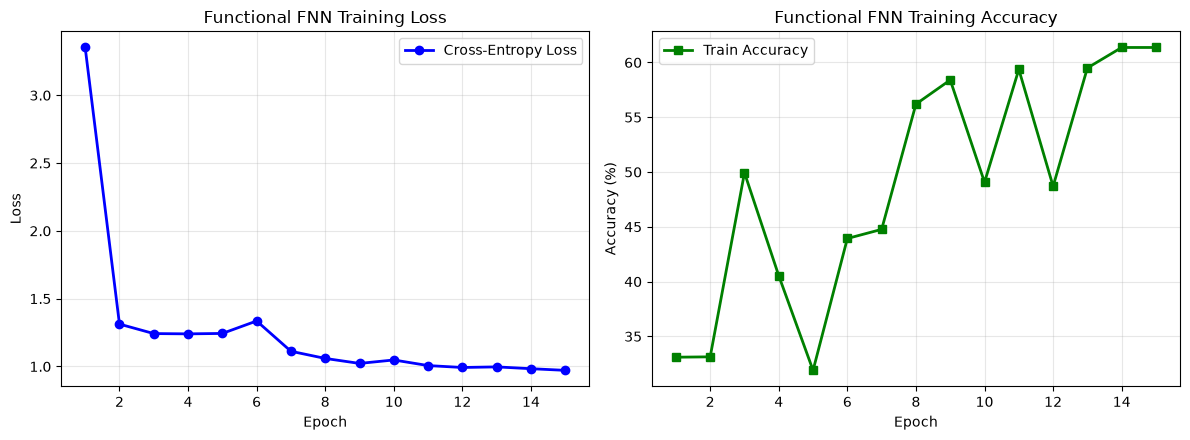

In [21]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history["loss"], "b-o", linewidth=2, label="Cross-Entropy Loss")
plt.title("Functional FNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history["accuracy"], "g-s", linewidth=2, label="Train Accuracy")
plt.title("Functional FNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

FNN Dense1 Activation L2 Distance under 10px shift: 0.2543 | Normalized: 0.0162
FNN Dense2 Activation L2 Distance under 10px shift: 0.1481 | Normalized: 0.0183
FNN Dense3 Activation L2 Distance under 10px shift: 0.0348 | Normalized: 0.0065


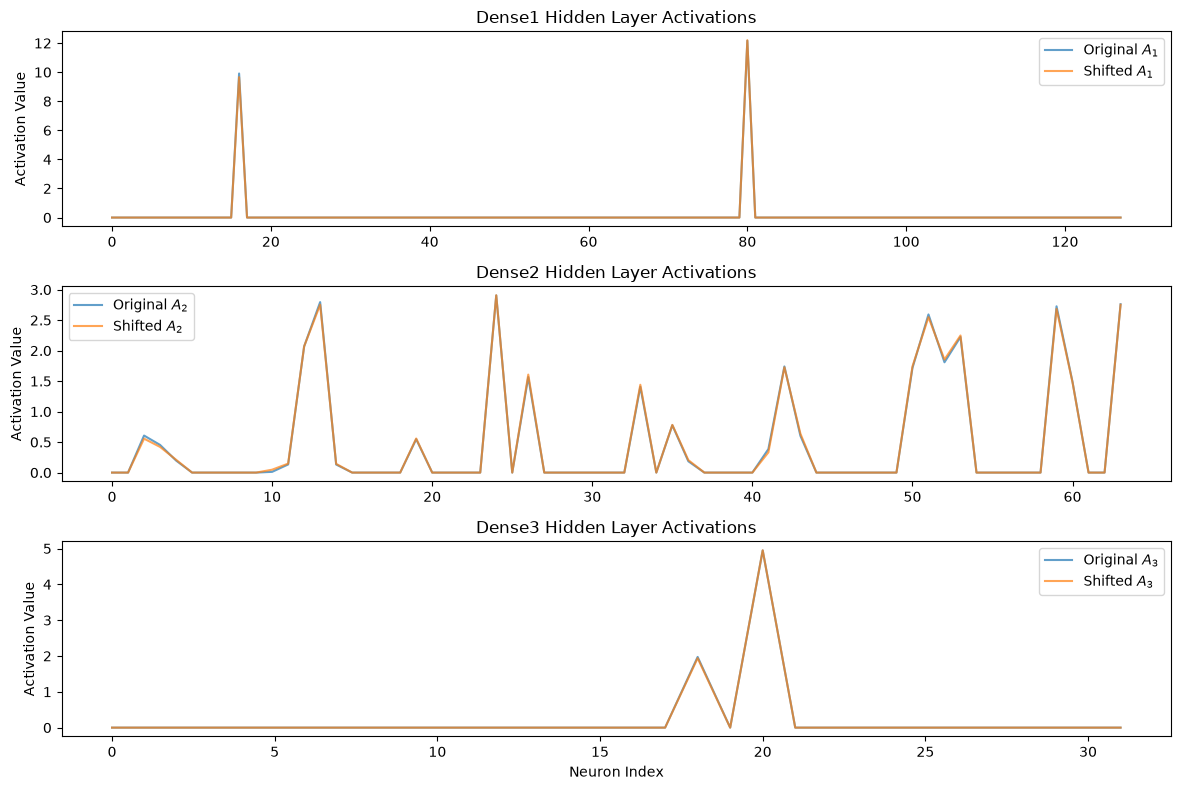

In [23]:
# Select one image for testing translation
sample_img = X_train[0:1]

# Translate 10 pixels to right
shift = 10
sample_shifted = np.roll(sample_img, shift=shift, axis=2)

# Extract Hidden Activations for original image
A0_orig, _ = flatten.forward(sample_img)
A1_orig, _ = dense1.forward(A0_orig)
A2_orig, _ = dense2.forward(A1_orig)
A3_orig, _ = dense3.forward(A2_orig)

# Extract Hidden Activations for shifted image
A0_shifted, _ = flatten.forward(sample_shifted)
A1_shifted, _ = dense1.forward(A0_shifted)
A2_shifted, _ = dense2.forward(A1_shifted)
A3_shifted, _ = dense3.forward(A2_shifted)

# Measure distance for each layer
layers = [
    ("Dense1", A1_orig, A1_shifted),
    ("Dense2", A2_orig, A2_shifted),
    ("Dense3", A3_orig, A3_shifted)
]

distances = []

for name, orig, shifted in layers:
    raw_dist = np.linalg.norm(orig - shifted)
    norm_dist = raw_dist / (np.linalg.norm(orig) + 1e-8)
    distances.append(norm_dist)

    print(
        f"FNN {name} Activation L2 Distance under "
        f"{shift}px shift: {raw_dist:.4f} | "
        f"Normalized: {norm_dist:.4f}"
    )

# Plot comparison
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(A1_orig.squeeze(), label="Original $A_1$", alpha=0.7)
plt.plot(A1_shifted.squeeze(), label="Shifted $A_1$", alpha=0.7)
plt.title("Dense1 Hidden Layer Activations")
plt.ylabel("Activation Value")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(A2_orig.squeeze(), label="Original $A_2$", alpha=0.7)
plt.plot(A2_shifted.squeeze(), label="Shifted $A_2$", alpha=0.7)
plt.title("Dense2 Hidden Layer Activations")
plt.ylabel("Activation Value")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(A3_orig.squeeze(), label="Original $A_3$", alpha=0.7)
plt.plot(A3_shifted.squeeze(), label="Shifted $A_3$", alpha=0.7)
plt.title("Dense3 Hidden Layer Activations")
plt.xlabel("Neuron Index")
plt.ylabel("Activation Value")
plt.legend()

plt.tight_layout()
plt.show()

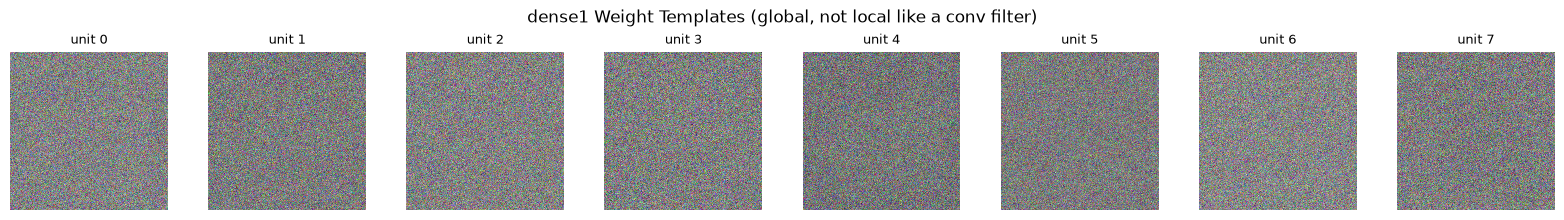

In [26]:
# FNN dense layers do not have local receptive fields like CNNs.
# Each dense1 neuron sees the entire flattened image with its own weights.

templates = dense1.W  # (128, 160*160*3)
n_show = 8
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.2))
for i, ax in enumerate(axes):
    t = templates[i].reshape(160, 160, 3)
    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-8)
    ax.imshow(t_norm, interpolation="nearest")
    ax.set_title(f"unit {i}", fontsize=9)
    ax.axis("off")
fig.suptitle("dense1 Weight Templates (global, not local like a conv filter)")
plt.tight_layout()
plt.show()
